In [ ]:
!pip install torch_geometric

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import numpy as np
def prepare_splits(dataset, val_size, test_size, splitting_scheme, N_folds=1, seed=42):

    if splitting_scheme == "random":
# Random classic split
       all_idx = list(range(len(dataset)))
       trainval_idx, test_idx = train_test_split(all_idx, test_size=test_size, random_state=seed)
       rel_val_size = val_size / (1.0 - test_size)
       train_idx_dict, val_idx_dict = {}, {}
       for fold in range(N_folds):
           train_idx, val_idx = train_test_split(trainval_idx, test_size=rel_val_size,
           random_state=seed + fold)
           train_idx_dict[fold] = list(train_idx)
           val_idx_dict[fold] = list(val_idx)
       return train_idx_dict, val_idx_dict, list(test_idx)
    elif splitting_scheme == "unseen_interventions":
# Train/Val/Test has unique interventions
# Group by intervention
        group_keys = [tuple(np.nonzero(item['intervention'].cpu().numpy())[0].tolist()) for item in
                 dataset]
        unique_map = {k: i for i, k in enumerate(dict.fromkeys(group_keys))}
        groups_int = np.array([unique_map[k] for k in group_keys], dtype=int)
        all_idx = list(range(len(dataset)))
        X = np.arange(len(all_idx))
# test
        gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        _, test_idx = next(gss_test.split(X=X, groups=groups_int))
        test_idx = list(test_idx)
        pool_index = [i for i in all_idx if i not in set(test_idx)]
        rel_val_size = val_size / (1.0 - test_size)
        pool_groups = groups_int[pool_index]
        X_pool = np.arange(len(pool_index))
#Train and validation
        train_idx_dict, val_idx_dict = {}, {}
        for fold in range(N_folds):
            gss_val = GroupShuffleSplit(n_splits=1, test_size=rel_val_size, random_state=seed
                  + fold)
            train_rel, val_rel = next(gss_val.split(X=X_pool, groups=pool_groups))
            train_idx = [pool_index[i] for i in train_rel]
            val_idx = [pool_index[i] for i in val_rel]
            train_idx_dict[fold] = list(train_idx)
            val_idx_dict[fold] = list(val_idx)
        return train_idx_dict, val_idx_dict, list(test_idx)
    else:
        raise ValueError("splitting_scheme must be 'random' or 'unseen_interventions'")

In [ ]:
import torch
import torch_geometric

#A549 = torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_A549.pt', weights_only=False )
#HT29 =  torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_HT29.pt' , weights_only=False)
PC3 =  torch.load('/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/data/data_backward_PC3.pt', weights_only=False )


# Analisis de los datos

- diseased : Vector de $10.716$ , Niveles de ARN de la célula enferma (antes)
- intervention : Vector de $10.716$ bianrio, con 1 en el gen eliminado
- treated : Vector de $10.716$ , Niveles de ARN de la célula despues
- gene_symbols : Lista de nombres de cada gen



# Task 1: Regresion Lineal

La entrada seran 2 cosas:
- Estado inicial (vector de 10.716 genes antes de tocar nada) (diseased)
- El gen especifico que hacemos knocout (intervention)

La salida de esto sera el estado que intentamos predecir y hay que comparalo con el real (treated)

Para seleccionar los genes vamos a usar 3 formas diferentes :
1. Primero vamos a coger todos los genes que al menos una vez aparezcan como 1 en el vector de intervention.
2. Luego seleccionaremos los top diferencially expresed genes , los cuales son los que mas cambian entre el estado diseased y el estado treated .
3. Por ultimo cogeremos los 2000 genes con mayor varianza (HVG).

Juntaremos todos los escogidos por los 3 metodos y quitaremos los duplicados. Esto se hace sobre los datos del train para evitar fuga de datos

In [ ]:
# primero separamos el train test
train_idx_dict, val_idx_dict, test_idx = prepare_splits(dataset = PC3 , val_size= 0.1 , test_size=0.1 , splitting_scheme ="unseen_interventions")
# nos quedamos con el primer fold
train_idx = train_idx_dict[0]
val_idx = val_idx_dict[0]

In [ ]:
import numpy as np
# Forma 1 :
# Sumamos todo el vector de intervencion y si es mayor que 1 es que el gen fue usado :
all_interventions = torch.stack([d.intervention for d in PC3]).sum(dim=0)
idx_perturbed = torch.where(all_interventions > 0)[0].numpy()

# Forma 2 :
# Calculamos la diferencia media absoluta entre diseased y treated
diffs = []
for i in train_idx:
    d = PC3[i]
    diffs.append(torch.abs(d.treated - d.diseased))
mean_diffs = torch.stack(diffs).mean(dim=0)
# guardamos los 1000 que más cambian
idx_degs = torch.topk(mean_diffs, k=1000).indices.numpy()

final_gene_indices = np.unique(np.concatenate([idx_perturbed, idx_degs]))

print(f"Tenemos {len(final_gene_indices)} genes selecionados.")

Tenemos 4216 genes selecionados.


In [ ]:
diseased_tensor = torch.stack([d.diseased for d in PC3])
intervention_tensor = torch.stack([d.intervention for d in PC3])
treated_tensor = torch.stack([d.treated for d in PC3])

# nos quedamos con los genes selecionados en los 3 tensores
diseased_matrix = diseased_tensor[:, final_gene_indices].numpy()
treated_matrix = treated_tensor[:, final_gene_indices].numpy()
intervention_matrix = intervention_tensor[:, final_gene_indices].numpy()

print(diseased_matrix.shape)
print(treated_matrix.shape)
print(intervention_matrix.shape)



(21229, 4216)
(21229, 4216)
(21229, 4216)


In [ ]:
from sklearn.linear_model import Ridge

X_train = np.concatenate([diseased_matrix[train_idx], intervention_matrix[train_idx]], axis=1)
y_train = treated_matrix[train_idx]

X_val = np.concatenate([diseased_matrix[val_idx], intervention_matrix[val_idx]], axis=1)
y_val = treated_matrix[val_idx]

X_test = np.concatenate([diseased_matrix[test_idx], intervention_matrix[test_idx]], axis=1)
y_test = treated_matrix[test_idx]

ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)

y_pred_test = ridge.predict(X_test)

In [ ]:
mse_test = np.mean((y_test - y_pred_test)**2)
print(f"MSE: {mse_test:.4f}")

MSE: 0.0255


In [ ]:
from scipy.stats import pearsonr
def samplewise_r2(y_true, y_pred):
   y_true = np.asarray(y_true)
   y_pred = np.asarray(y_pred)
   n_samples = y_true.shape[0]
   r2 = np.empty(n_samples, dtype=float)
   for i in range(n_samples):
      r2[i] = pearsonr(y_true[i], y_pred[i])[0] ** 2
   return r2
r2 = samplewise_r2(y_test, y_pred_test)
print(r2.shape)
print(f'R2: {r2.mean()}')

(2067,)
R2: 0.8888174258947488


In [ ]:
def gene_var_score(y_true, y_pred, eps=1e-12):

   y_true = np.asarray(y_true)
   y_pred = np.asarray(y_pred)
   var_true = np.var(y_true, axis=0)
   var_pred = np.var(y_pred, axis=0)
   ratio = (var_pred + eps) / (var_true + eps)
   score = np.exp(-np.abs(np.log(ratio)))
   return score

variance_score = gene_var_score(y_test, y_pred_test)
print(variance_score.shape)
print(f'Varianza por gen: {variance_score.mean()}')

(4216,)
Varianza por gen: 0.05542369186878204


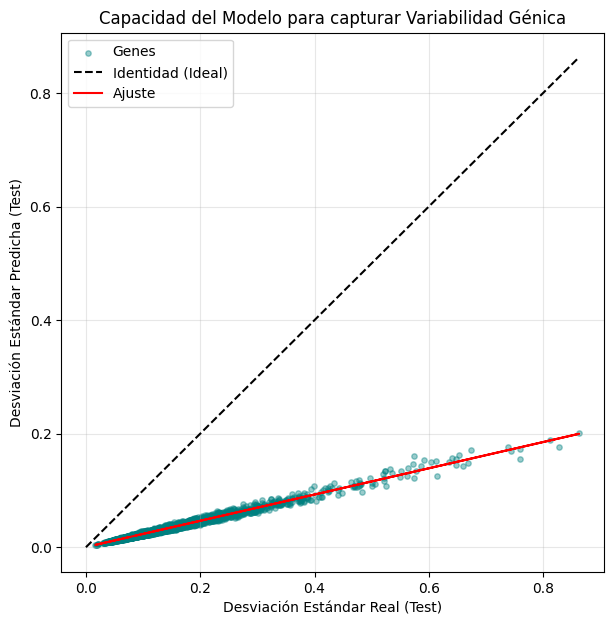

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

std_true = np.std(y_test, axis=0)
std_pred = np.std(y_pred_test, axis=0)

slope, intercept, r_value, p_value, std_err = linregress(std_true, std_pred)

plt.figure(figsize=(7, 7))
plt.scatter(std_true, std_pred, alpha=0.4, s=15, color='teal', label='Genes')
plt.plot([0, std_true.max()], [0, std_true.max()], 'k--', label='Identidad (Ideal)')
plt.plot(std_true, slope*std_true + intercept, color='red',
         label=f'Ajuste')

plt.xlabel('Desviación Estándar Real (Test)')
plt.ylabel('Desviación Estándar Predicha (Test)')
plt.title('Capacidad del Modelo para capturar Variabilidad Génica')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Tenemos 4207 genes selecionados del dataset A549.
MSE de A549: 0.0279
R2 de A549: 0.8843930326687598
Varianza por gen de A549: 0.047591522336006165
Tenemos 4199 genes selecionados del dataset HT29.
MSE de HT29: 0.0240
R2 de HT29: 0.8973132653022879
Varianza por gen de HT29: 0.049302149564027786
Tenemos 4216 genes selecionados del dataset PC3.
MSE de PC3: 0.0255
R2 de PC3: 0.8888174258947488
Varianza por gen de PC3: 0.05542369186878204


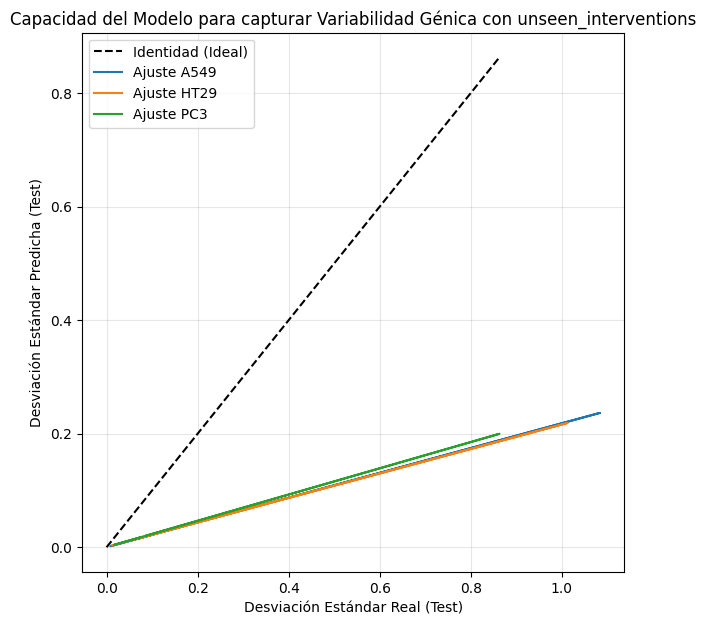

In [ ]:

# Ahora para las otras 2 lineas celulares definiendo una funcion
def hacer_ridge_con_split(dataset,split,label_name):

    # primero separamos el train test
    train_idx_dict, val_idx_dict, test_idx = prepare_splits(dataset = dataset , val_size= 0.1 , test_size=0.1 , splitting_scheme = split)

    # nos quedamos con el primer fold
    train_idx = train_idx_dict[0]
    val_idx = val_idx_dict[0]

    # Seleccionamos los mejores genes (Como he explicado antes)
    all_interventions = torch.stack([d.intervention for d in dataset]).sum(dim=0)
    idx_perturbed = torch.where(all_interventions > 0)[0].numpy()

    diffs = []
    for i in train_idx:
        d = dataset[i]
        diffs.append(torch.abs(d.treated - d.diseased))
    mean_diffs = torch.stack(diffs).mean(dim=0)
    idx_degs = torch.topk(mean_diffs, k=1000).indices.numpy()

    final_gene_indices = np.unique(np.concatenate([idx_perturbed, idx_degs]))

    print(f"Tenemos {len(final_gene_indices)} genes selecionados del dataset {label_name}.")


    diseased_tensor = torch.stack([d.diseased for d in dataset])
    intervention_tensor = torch.stack([d.intervention for d in dataset])
    treated_tensor = torch.stack([d.treated for d in dataset])

    diseased_matrix = diseased_tensor[:, final_gene_indices].numpy()
    treated_matrix = treated_tensor[:, final_gene_indices].numpy()
    intervention_matrix = intervention_tensor[:, final_gene_indices].numpy()
    # Modelo
    X_train = np.concatenate([diseased_matrix[train_idx], intervention_matrix[train_idx]], axis=1)
    y_train = treated_matrix[train_idx]

    X_val = np.concatenate([diseased_matrix[val_idx], intervention_matrix[val_idx]], axis=1)
    y_val = treated_matrix[val_idx]

    X_test = np.concatenate([diseased_matrix[test_idx], intervention_matrix[test_idx]], axis=1)
    y_test = treated_matrix[test_idx]

    ridge = Ridge(alpha=10.0)
    ridge.fit(X_train, y_train)

    y_pred_test = ridge.predict(X_test)

    mse_test = np.mean((y_test - y_pred_test)**2)
    print(f"MSE de {label_name}: {mse_test:.4f}")

    r2 = samplewise_r2(y_test, y_pred_test)
    print(f'R2 de {label_name}: {r2.mean()}')
    variance_score = gene_var_score(y_test, y_pred_test)
    print(f'Varianza por gen de {label_name}: {variance_score.mean()}')

    std_true = np.std(y_test, axis=0)
    std_pred = np.std(y_pred_test, axis=0)

    slope, intercept, r_value, p_value, std_err = linregress(std_true, std_pred)

    plt.plot(std_true, slope*std_true + intercept, label=f'Ajuste {label_name}')

    return y_pred_test

plt.figure(figsize=(7, 7))
plt.xlabel('Desviación Estándar Real (Test)')
plt.ylabel('Desviación Estándar Predicha (Test)')
plt.title('Capacidad del Modelo para capturar Variabilidad Génica con unseen_interventions')
plt.plot([0, std_true.max()], [0, std_true.max()], 'k--', label='Identidad (Ideal)')


y_pred_A549_unse = hacer_ridge_con_split(dataset = A549, split = 'unseen_interventions', label_name = 'A549')
y_pred_HT29_unse = hacer_ridge_con_split(dataset = HT29, split = 'unseen_interventions',label_name = 'HT29')
y_pred_PC3_unse = hacer_ridge_con_split(dataset = PC3 ,  split = 'unseen_interventions',label_name = 'PC3')

plt.legend()
plt.grid(alpha=0.3)



Tenemos 4208 genes selecionados del dataset A549.
MSE de A549: 0.0232
R2 de A549: 0.9026068704784752
Varianza por gen de A549: 0.09702766686677933
Tenemos 4199 genes selecionados del dataset HT29.
MSE de HT29: 0.0198
R2 de HT29: 0.9140761271518321
Varianza por gen de HT29: 0.08690591901540756
Tenemos 4218 genes selecionados del dataset PC3.
MSE de PC3: 0.0212
R2 de PC3: 0.9071207342426337
Varianza por gen de PC3: 0.09335657954216003


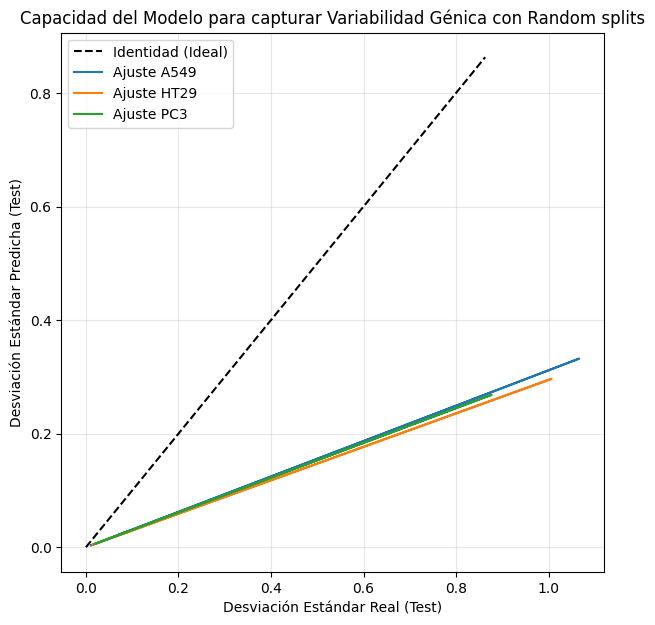

In [ ]:
# Hacemos lo mismo pero con Random splits
plt.figure(figsize=(7, 7))
plt.xlabel('Desviación Estándar Real (Test)')
plt.ylabel('Desviación Estándar Predicha (Test)')
plt.title('Capacidad del Modelo para capturar Variabilidad Génica con Random splits')
plt.plot([0, std_true.max()], [0, std_true.max()], 'k--', label='Identidad (Ideal)')


y_pred_A549_unse = hacer_ridge_con_split(dataset = A549, split = 'random', label_name = 'A549')
y_pred_HT29_unse = hacer_ridge_con_split(dataset = HT29, split = 'random',label_name = 'HT29')
y_pred_PC3_unse = hacer_ridge_con_split(dataset = PC3 ,  split = 'random',label_name = 'PC3')

plt.legend()
plt.grid(alpha=0.3)

# Task 2: Modelo de DIFUSION en espacio latente

Para mejorar este baseline voy a usar un modelo de difusion en un espacio latente, para esto primero tenemos que hacer un AE capaz de coger los 4216 genes y comprimirlos a un espacio latente de 128 dim .

In [ ]:
import torch
import torch.nn as nn

class AutoencoderSC(nn.Module):
    def __init__(self, n_genes):
        super().__init__()
        # Encoder: Comprime la información a espacio latente
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),


            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,128)
        )
        # Decoder: Reconstruye los genes
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, n_genes)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred, z

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
# unimos el dieased y el treated para hacer los data loader porque el autoencoder tiene que reconstruir los datos (comprimir y descomprimir)
ae_train = torch.tensor(np.vstack([diseased_matrix[train_idx], treated_matrix[train_idx]]),dtype= torch.float32)
ae_val = torch.tensor(np.vstack([diseased_matrix[val_idx], treated_matrix[val_idx]]),dtype= torch.float32)
ae_test = torch.tensor(np.vstack([diseased_matrix[test_idx], treated_matrix[test_idx]]),dtype= torch.float32)

dataset_ae_train = TensorDataset(ae_train, ae_train)
dataset_ae_val = TensorDataset(ae_val, ae_val)
dataset_ae_test = TensorDataset(ae_test, ae_test)

dataloader_ae_train = DataLoader(dataset_ae_train, batch_size=128, shuffle=True)
dataloader_ae_val = DataLoader(dataset_ae_val, batch_size=128, shuffle=False)
dataloader_ae_test = DataLoader(dataset_ae_test, batch_size=128, shuffle=False)

print(f"Muestras para entrenar el AE: {len(dataset_ae_train)}")
print(f"Batches por epoch en train: {len(dataloader_ae_train)}")

Muestras para entrenar el AE: 34118
Batches por epoch en train: 267


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = AutoencoderSC(n_genes= len(final_gene_indices) ).to(device)
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
loss_fn_ae = nn.SmoothL1Loss()  # usamos esta y no MSE porque es menos sensible a valores extremos

epochs_ae = 150
'''
for epoch in range(epochs_ae):
    # ENTRENAMIENTO
    autoencoder.train()
    loss_total = 0
    for x_batch, _ in dataloader_ae_train:
        x_batch = x_batch.to(device)

        x_pred, z = autoencoder(x_batch)
        loss = loss_fn_ae(x_pred, x_batch)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        loss_total += loss.item()

    # VALIDACIÓN
    autoencoder.eval()
    val_loss_total = 0
    with torch.no_grad():
        for x_val, _ in dataloader_ae_val:
            x_val = x_val.to(device)

            x_pred_val, _ = autoencoder(x_val)
            val_loss = loss_fn_ae(x_pred_val, x_val)

            val_loss_total += val_loss.item()


    if (epoch + 1) % 10 == 0:
        train_loss_avg = loss_total / len(dataloader_ae_train)
        val_loss_avg = val_loss_total / len(dataloader_ae_val)
        print(f"AE Epoch [{epoch+1}/{epochs_ae}] | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_loss_avg:.4f}")'''


AE Epoch [10/150] | Train Loss: 0.0118 | Validation Loss: 0.0140
AE Epoch [20/150] | Train Loss: 0.0093 | Validation Loss: 0.0071
AE Epoch [30/150] | Train Loss: 0.0076 | Validation Loss: 0.0065
AE Epoch [40/150] | Train Loss: 0.0068 | Validation Loss: 0.0074
AE Epoch [50/150] | Train Loss: 0.0064 | Validation Loss: 0.0063
AE Epoch [60/150] | Train Loss: 0.0059 | Validation Loss: 0.0052
AE Epoch [70/150] | Train Loss: 0.0058 | Validation Loss: 0.0049
AE Epoch [80/150] | Train Loss: 0.0057 | Validation Loss: 0.0051
AE Epoch [90/150] | Train Loss: 0.0055 | Validation Loss: 0.0055
AE Epoch [100/150] | Train Loss: 0.0054 | Validation Loss: 0.0066
AE Epoch [110/150] | Train Loss: 0.0054 | Validation Loss: 0.0046
AE Epoch [120/150] | Train Loss: 0.0053 | Validation Loss: 0.0070
AE Epoch [130/150] | Train Loss: 0.0051 | Validation Loss: 0.0044
AE Epoch [140/150] | Train Loss: 0.0051 | Validation Loss: 0.0039
AE Epoch [150/150] | Train Loss: 0.0050 | Validation Loss: 0.0044


In [ ]:
#torch.save(autoencoder.state_dict(), '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/autoencoder_pesos.pth')

In [ ]:
# Le cargamos los pesos del Drive
ruta_guardado = '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/autoencoder_pesos.pth'
autoencoder.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación y lo congelamos
autoencoder.eval()
for param in autoencoder.parameters():
    param.requires_grad = False # Congela los pesos,

print("Autoencoder cargado y listo")

Autoencoder cargado y listo


DIFUSION MODEL:

In [ ]:
import math
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    def __init__(self, dim, cond_dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.act1 = nn.SiLU()
        self.linear2 = nn.Linear(dim, dim)
        self.act2 = nn.SiLU()

        # Capa para inyectar el contexto
        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # El contexto modifica el estado oculto de la célula
        h = self.linear1(x) + self.cond_proj(cond)
        h = self.act1(h)
        h = self.linear2(h)
        return h + x # Conexión residual (suma la entrada original)

class PerturbationDiffusion(nn.Module):
    def __init__(self, latent_dim=128, diseased_dim=128, intervention_dim = len(final_gene_indices), hidden_dim=512, cond_dim=256):
      super().__init__()
      self.latent_dim = latent_dim
       # embedding de la t
      self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(cond_dim),
            nn.Linear(cond_dim, cond_dim),
            nn.SiLU()
        )
      # Procesador del estado basal 'diseased'
      self.diseased_mlp = nn.Sequential(
            nn.Linear(diseased_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
      # Procesador de la intervención
      self.intervention_mlp = nn.Sequential(
            nn.Linear(intervention_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim)
        )
      # Capa de entrada (recibe el latente ruidoso de la célula treated)
      self.init_lin = nn.Linear(latent_dim, hidden_dim)

      # Bloques residuales
      self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim),
            ResidualBlock(hidden_dim, cond_dim)
        ])
      # Capa de salida (predice el ruido añadido)
      self.out_lin = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x_t, t, diseased_state, intervention_vector):
        # Calculamos los 3 embeddings
        t_emb = self.time_mlp(t)
        dis_emb = self.diseased_mlp(diseased_state)
        int_emb = self.intervention_mlp(intervention_vector)

        # Sumamos
        # "Nivel de ruido T" + "Estado Genético Previo" + "Gen Apagado"
        context = t_emb + dis_emb + int_emb

        # Pasamos el vector (con ruido) por la red de bloques residuales
        x = self.init_lin(x_t)

        for block in self.blocks:
            x = block(x, context) # Inyectamos el contexto biológico en cada capa

        # Predecimos el ruido para limpiar
        ruido_predicho = self.out_lin(x)
        return ruido_predicho

In [ ]:
def train_step_perturbation(model, z_0_treated, diseased_state, intervention_vector, optimizer):
# z_0_treated: El estado FINAL de la célula (comprimido a latente por el Autoencoder) objetivo
# diseased_state: El estado INICIAL de la célula (comprimido a latente)
# intervention_vector: Los genes apagados (unos y ceros, 4216 dims)
    model.train()
    optimizer.zero_grad()

    device = z_0_treated.device
    batch_size = z_0_treated.shape[0]

    # Tiempo aleatorio para cada célula del batch (t entre 0 y 1)
    t = torch.rand(batch_size, device=device).unsqueeze(1)

    # Ruido puro (Epsilon)
    epsilon = torch.randn_like(z_0_treated).to(device)

    # COSINE SCHEDULE
    theta = t * (math.pi / 2)
    alpha_t = torch.cos(theta) # Proporción de señal original
    sigma_t = torch.sin(theta) # Proporción de ruido

    # Ensuciaremos el estado FINAL (treated). El modelo tendrá que aprender a limpiarlo.
    z_t = alpha_t * z_0_treated + sigma_t * epsilon
    pred_noise = model(z_t, t.squeeze(1), diseased_state, intervention_vector)
    loss = nn.MSELoss()(pred_noise, epsilon)
    loss.backward()
    optimizer.step()

    return loss.item()



In [ ]:
# Vamos a crear los data loader pasando los datos primero por el encoder y luego escalando antes de entrar al modelo de difusion
from sklearn.preprocessing import StandardScaler
autoencoder.eval()

with torch.no_grad():
    # TRAIN
    x_dis_train = torch.tensor(diseased_matrix[train_idx], dtype=torch.float32).to(device)
    y_tre_train = torch.tensor(treated_matrix[train_idx], dtype=torch.float32).to(device)

    z_dis_train = autoencoder.encoder(x_dis_train).cpu().numpy() # Bajamos a CPU para el Scaler
    z_tre_train = autoencoder.encoder(y_tre_train).cpu().numpy()

    int_train = torch.tensor(intervention_matrix[train_idx], dtype=torch.float32).to(device)

    # VALIDATION
    x_dis_val = torch.tensor(diseased_matrix[val_idx], dtype=torch.float32).to(device)
    y_tre_val = torch.tensor(treated_matrix[val_idx], dtype=torch.float32).to(device)

    z_dis_val = autoencoder.encoder(x_dis_val).cpu().numpy()
    z_tre_val = autoencoder.encoder(y_tre_val).cpu().numpy()

    int_val = torch.tensor(intervention_matrix[val_idx], dtype=torch.float32).to(device)

    # TEST
    x_dis_test = torch.tensor(diseased_matrix[test_idx], dtype=torch.float32).to(device)
    y_tre_test = torch.tensor(treated_matrix[test_idx], dtype=torch.float32).to(device)

    z_dis_test = autoencoder.encoder(x_dis_test).cpu().numpy()
    z_tre_test = autoencoder.encoder(y_tre_test).cpu().numpy()

    int_test = torch.tensor(intervention_matrix[test_idx], dtype=torch.float32).to(device)

# Scaler entrenado solo con los datos de train
scaler_latente = StandardScaler()
z_train_combinado = np.vstack([z_dis_train, z_tre_train])
scaler_latente.fit(z_train_combinado)

# Transformamos todos los conjuntos (Train, Val y Test)
z_dis_train_scaled = scaler_latente.transform(z_dis_train)
z_tre_train_scaled = scaler_latente.transform(z_tre_train)

z_dis_val_scaled = scaler_latente.transform(z_dis_val)
z_tre_val_scaled = scaler_latente.transform(z_tre_val)

z_dis_test_scaled = scaler_latente.transform(z_dis_test)
z_tre_test_scaled = scaler_latente.transform(z_tre_test)

BATCH_SIZE = 128

# DATALOADER DE TRAIN
z_tre_t_train = torch.tensor(z_tre_train_scaled, dtype=torch.float32).to(device)
z_dis_t_train = torch.tensor(z_dis_train_scaled, dtype=torch.float32).to(device)

dataset_train_diff = TensorDataset(z_tre_t_train, z_dis_t_train, int_train)
loader_train_diff = DataLoader(dataset_train_diff, batch_size=BATCH_SIZE, shuffle=True)

# DATALOADER DE VALIDATION
z_tre_t_val = torch.tensor(z_tre_val_scaled, dtype=torch.float32).to(device)
z_dis_t_val = torch.tensor(z_dis_val_scaled, dtype=torch.float32).to(device)

dataset_val_diff = TensorDataset(z_tre_t_val, z_dis_t_val, int_val)
loader_val_diff = DataLoader(dataset_val_diff, batch_size=BATCH_SIZE, shuffle=False)

# DATALOADER DE TEST
z_tre_t_test = torch.tensor(z_tre_test_scaled, dtype=torch.float32).to(device)
z_dis_t_test = torch.tensor(z_dis_test_scaled, dtype=torch.float32).to(device)

dataset_test_diff = TensorDataset(z_tre_t_test, z_dis_t_test, int_test)
loader_test_diff = DataLoader(dataset_test_diff, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches de Train Difusión: {len(loader_train_diff)}")

Batches de Train Difusión: 134


In [ ]:
latent_dim = 128
diseased_dim = 128
intervention_dim =  len(final_gene_indices)
model = PerturbationDiffusion(
    latent_dim=latent_dim,
    diseased_dim=diseased_dim,
    intervention_dim=intervention_dim
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

'''
for epoch in range(300):
    model.train()
    total_train_loss = 0

    # Tu DataLoader ahora escupe: (latente_treated, latente_diseased, vector_intervencion)
    for batch_z_treated, batch_z_diseased, batch_intervention in loader_train_diff:
        batch_z_treated = batch_z_treated.to(device)
        batch_z_diseased = batch_z_diseased.to(device)
        batch_intervention = batch_intervention.to(device)
        loss = train_step_perturbation(
            model, batch_z_treated, batch_z_diseased, batch_intervention, optimizer
        )
        total_train_loss += loss

    avg_train_loss = total_train_loss / len(loader_train_diff)


    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_z_treated, batch_z_diseased, batch_intervention in loader_val_diff:
            batch_z_treated = batch_z_treated.to(device)
            batch_z_diseased = batch_z_diseased.to(device)
            batch_intervention = batch_intervention.to(device)

            batch_size_val = batch_z_treated.shape[0]

            # Meter ruido paso a paso (igual que en tu TFM)
            t_val = torch.rand(batch_size_val, device=device).unsqueeze(1)
            epsilon_val = torch.randn_like(batch_z_treated).to(device)

            # Geometría del coseno
            theta_val = t_val * (math.pi / 2)
            alpha_t_val = torch.cos(theta_val)
            sigma_t_val = torch.sin(theta_val)

            # Célula con ruido
            z_t_val = alpha_t_val * batch_z_treated + sigma_t_val * epsilon_val

            # El modelo predice el ruido usando el contexto continuo
            pred_noise_val = model(z_t_val, t_val.squeeze(1), batch_z_diseased, batch_intervention)

            # Calculamos el error
            loss_val = criterion(pred_noise_val, epsilon_val)
            total_val_loss += loss_val.item()

    avg_val_loss = total_val_loss / len(loader_val_diff)


    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f}")
        '''


Epoch   0 | Train Loss (MSE): 0.7241 | Val Loss (MSE): 0.4474
Epoch  10 | Train Loss (MSE): 0.2792 | Val Loss (MSE): 0.2787
Epoch  20 | Train Loss (MSE): 0.2313 | Val Loss (MSE): 0.2337
Epoch  30 | Train Loss (MSE): 0.2165 | Val Loss (MSE): 0.2255
Epoch  40 | Train Loss (MSE): 0.2052 | Val Loss (MSE): 0.2272
Epoch  50 | Train Loss (MSE): 0.2028 | Val Loss (MSE): 0.2198
Epoch  60 | Train Loss (MSE): 0.1964 | Val Loss (MSE): 0.2128
Epoch  70 | Train Loss (MSE): 0.1889 | Val Loss (MSE): 0.2176
Epoch  80 | Train Loss (MSE): 0.1882 | Val Loss (MSE): 0.1993
Epoch  90 | Train Loss (MSE): 0.1848 | Val Loss (MSE): 0.2011
Epoch 100 | Train Loss (MSE): 0.1833 | Val Loss (MSE): 0.2100
Epoch 110 | Train Loss (MSE): 0.1828 | Val Loss (MSE): 0.2022
Epoch 120 | Train Loss (MSE): 0.1790 | Val Loss (MSE): 0.1961
Epoch 130 | Train Loss (MSE): 0.1783 | Val Loss (MSE): 0.2071
Epoch 140 | Train Loss (MSE): 0.1758 | Val Loss (MSE): 0.2074
Epoch 150 | Train Loss (MSE): 0.1759 | Val Loss (MSE): 0.1951
Epoch 16

In [ ]:
#torch.save(model.state_dict(), '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/difusion_pesos.pth')

In [ ]:
# Le cargamos los pesos del Drive
ruta_guardado =  '/content/drive/MyDrive/Master/Deep Learning/Trabajo Final/modelos/difusion_pesos.pth'
model.load_state_dict(torch.load(ruta_guardado))

# Lo ponemos en modo evaluación
model.eval()

print("Modelo de difusion cargado y listo")

Modelo de difusion cargado y listo


In [ ]:

@torch.no_grad()
def predecir_crispr_guidance(model, latentes_diseased, intervencion_real, t_start=0.95, num_steps=50, guidance_scale=3.0):
    """
    latentes_diseased: z_dis_t_test (escalado)
    intervencion_real: int_test (el vector real de CRISPR)
    """
    model.eval()
    device = latentes_diseased.device
    num_celulas = latentes_diseased.shape[0]

    intervencion_nula = torch.zeros_like(intervencion_real, device=device)

    # Ruido inicial sobre el estado DISEASED
    t_inicial = torch.full((num_celulas, 1), t_start, device=device)
    epsilon = torch.randn_like(latentes_diseased)

    theta_inicial = t_inicial * (math.pi / 2)
    alpha_inicial = torch.cos(theta_inicial)
    sigma_inicial = torch.sin(theta_inicial)

    # Añadimos un 95% de ruido a la célula enferma original
    z = alpha_inicial * latentes_diseased + sigma_inicial * epsilon

    # Creamos los pasos de tiempo (desde t_start hasta 0)
    tiempos = torch.linspace(t_start, 0.0, num_steps + 1, device=device)

    # Contrastive Guidance
    for i in range(num_steps):
        t_actual = tiempos[i] * torch.ones((num_celulas, 1), device=device)
        t_siguiente = tiempos[i+1] * torch.ones((num_celulas, 1), device=device)

        # Geometría actual
        theta_actual = t_actual * (math.pi / 2)
        alpha_actual = torch.clamp(torch.cos(theta_actual), min=1e-4)
        sigma_actual = torch.sin(theta_actual)

        # Geometría siguiente
        theta_siguiente = t_siguiente * (math.pi / 2)
        alpha_siguiente = torch.clamp(torch.cos(theta_siguiente), min=1e-4)
        sigma_siguiente = torch.sin(theta_siguiente)

        # Predicción ORIGEN
        pred_noise_origen = model(z, t_actual.squeeze(1), latentes_diseased, intervencion_nula)

        # Predicción DESTINO
        pred_noise_destino = model(z, t_actual.squeeze(1), latentes_diseased, intervencion_real)

        # APLICAMOS LA GUÍA
        pred_noise = pred_noise_origen + guidance_scale * (pred_noise_destino - pred_noise_origen)

        # Estimación z_0 (Célula tratada limpia)
        z_0_pred = (z - sigma_actual * pred_noise) / alpha_actual

        # Paso DDIM al siguiente t
        z = alpha_siguiente * z_0_pred + sigma_siguiente * pred_noise

    return z

In [ ]:
z_pred_latente_escalado = predecir_crispr_guidance(
    model=model,
    latentes_diseased=z_dis_t_test,
    intervencion_real=int_test,
    t_start=0.99,
    num_steps=50,
    guidance_scale= 8.0
)

# Desescalamos
z_pred_numpy = z_pred_latente_escalado.cpu().numpy()
z_pred_real = scaler_latente.inverse_transform(z_pred_numpy)
z_pred_tensor = torch.tensor(z_pred_real, dtype=torch.float32).to(device)

# Decoder
autoencoder.eval()
with torch.no_grad():
    y_pred_diffusion_tensor = autoencoder.decoder(z_pred_tensor)

y_pred_diffusion = y_pred_diffusion_tensor.cpu().numpy()



In [ ]:
# Metricas
mse_diff = np.mean((y_test - y_pred_diffusion)**2)
r2_diff = samplewise_r2(y_test, y_pred_diffusion)
gv_diff = gene_var_score(y_test, y_pred_diffusion)

print(f"MSE: {mse_diff:.4f} (Ridge era 0.0255)")
print(f"R2 Sample-wise (Mean): {np.mean(r2_diff):.4f} (Ridge era 0.8846)")
print(f"Gene Variance Score (Mean): {np.mean(gv_diff):.4f} (Ridge era 0.0554)")

MSE: 0.0516 (Ridge era 0.0255)
R2 Sample-wise (Mean): 0.8000 (Ridge era 0.8846)
Gene Variance Score (Mean): 0.7577 (Ridge era 0.0554)


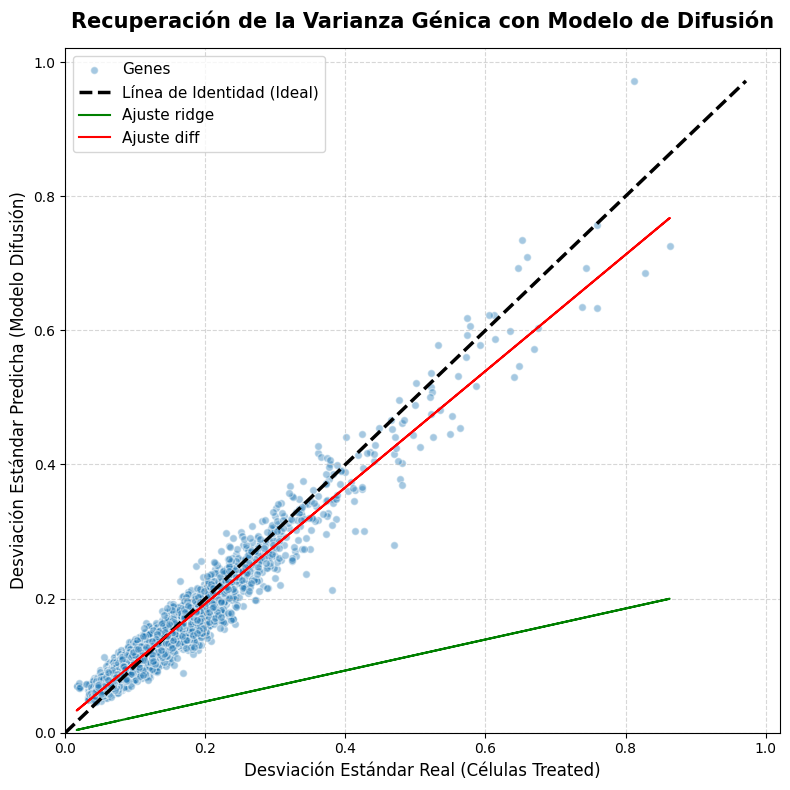

In [ ]:
# Calculamos la desviación estándar (variabilidad) de cada gen en la realidad y en la predicción
std_real = np.std(y_test, axis=0)
std_pred_diff = np.std(y_pred_diffusion, axis=0)

plt.figure(figsize=(8, 8))

# Dibujamos los puntos (cada punto es uno de tus miles de genes)
plt.scatter(std_real, std_pred_diff, alpha=0.4, color='#1f77b4', edgecolors='white', s=30, label='Genes')

slope_dif, intercept_dif, r_value_dif, p_value_dif, std_err_diff = linregress(std_true, std_pred_diff)

# Dibujamos la línea de Identidad (La perfección: si real=0.8, pred=0.8)
max_val = max(np.max(std_real), np.max(std_pred_diff))
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2.5, label='Línea de Identidad (Ideal)')
plt.plot(std_true, slope*std_true + intercept, color='green',
         label=f'Ajuste ridge')
plt.plot(std_true, slope_dif*std_true + intercept_dif, color='red',
         label=f'Ajuste diff')

plt.title("Recuperación de la Varianza Génica con Modelo de Difusión", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Desviación Estándar Real (Células Treated)", fontsize=12)
plt.ylabel("Desviación Estándar Predicha (Modelo Difusión)", fontsize=12)

plt.xlim(0, max_val * 1.05)
plt.ylim(0, max_val * 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

Mejora bastante, ahora en el siguiente colab haremos lo mismo pero para diferentes splits y tambien para todas las lineas celulares

--------------------------------------